In [11]:
# 1. Install the library needed to download the AI
!pip install transformers accelerate -q

# 2. Import the math engine
import torch

# 3. Check if the GPU is awake and ready
if torch.cuda.is_available():
    print(f"Success! Connected to GPU: {torch.cuda.get_device_name(0)}")
else:
    print("GPU not found. Go to Runtime > Change runtime type and select T4 GPU.")

Success! Connected to GPU: Tesla T4


In [12]:
# 4. Define which version of the AI we want to use
model_name = "facebook/esm2_t33_650M_UR50D"

# 5. Import the tools to load the model from the internet
from transformers import AutoTokenizer, AutoModelForMaskedLM

print("Downloading the dictionary (tokenizer)...")
tokenizer = AutoTokenizer.from_pretrained(model_name)

print("Downloading the AI brain (this will take 10-30 seconds)...")
model = AutoModelForMaskedLM.from_pretrained(model_name)

# 6. Move the heavy AI brain onto the GPU graphics card
model = model.to("cuda")

# 7. Tell the AI it is in "testing mode", not "learning mode"
model.eval()

print("Success! Model is loaded onto the GPU and ready.")

Loading weights:   0%|          | 0/539 [00:00<?, ?it/s]

Success! Model is loaded onto the GPU and ready.


In [13]:
import torch.nn.functional as F

# 1. Let's use a tiny 10-letter protein sequence to test
sequence = "MQIFVKTLTG"
print("Original Sequence: ", sequence)

# 2. Turn the letters into numbers (the tokenizer dictionary at work)
inputs = tokenizer(sequence, return_tensors="pt").to("cuda")

# 3. We want to blank out the 2nd letter ('Q').
# The AI secretly adds a "START" marker at position 0.
# So the 1st letter 'M' is at position 1. The 2nd letter 'Q' is at position 2.
blank_position = 2

# Replace the 'Q' with the AI's special code for [BLANK]
inputs["input_ids"][0, blank_position] = tokenizer.mask_token_id

# 4. Ask the AI engine to guess the blank (without permanently changing its memory)
import torch
with torch.no_grad():
    output = model(**inputs)

# 5. Look at the AI's raw math scores specifically for our blank spot
raw_scores = output.logits[0, blank_position]

# Convert the raw math scores into percentages (0 to 100%)
percentages = F.softmax(raw_scores, dim=-1)

# 6. Grab the Top 3 amino acids the AI strongly believes belong there
top3_scores, top3_ids = torch.topk(percentages, 3)

print("\n--- AI PREDICTIONS FOR THE BLANK SPOT ---")
for percentage, token_id in zip(top3_scores, top3_ids):
    # Translate the winning numbers back into English letters
    amino_acid = tokenizer.convert_ids_to_tokens(token_id.item())
    print(f"Amino Acid '{amino_acid}': {percentage.item() * 100:.1f}% confidence")

Original Sequence:  MQIFVKTLTG

--- AI PREDICTIONS FOR THE BLANK SPOT ---
Amino Acid 'L': 11.2% confidence
Amino Acid 'S': 7.9% confidence
Amino Acid 'K': 7.7% confidence


In [14]:
import torch

# 1. Grab the AI's confidence for the ORIGINAL letter ('Q')
wt_token_id = tokenizer.convert_tokens_to_ids("Q")
wt_confidence = percentages[wt_token_id].item()

# 2. Grab the AI's confidence for our MUTANT letter ('L')
mut_token_id = tokenizer.convert_tokens_to_ids("L")
mut_confidence = percentages[mut_token_id].item()

# 3. Calculate the Log-Likelihood Ratio (LLR) score
# We use torch.log to compare their evolutionary probabilities
llr_score = torch.log(torch.tensor(mut_confidence)) - torch.log(torch.tensor(wt_confidence))

print(f"Original 'Q' confidence: {wt_confidence * 100:.2f}%")
print(f"Mutant 'L' confidence:   {mut_confidence * 100:.2f}%")
print(f"\nMutation Score (LLR):    {llr_score.item():.3f}")

if llr_score > 0:
    print("AI Verdict: Likely STABLE / BENEFICIAL (AI prefers 'L' over 'Q')")
else:
    print("AI Verdict: Likely UNSTABLE / HARMFUL (AI prefers original 'Q')")

Original 'Q' confidence: 3.95%
Mutant 'L' confidence:   11.15%

Mutation Score (LLR):    1.038
AI Verdict: Likely STABLE / BENEFICIAL (AI prefers 'L' over 'Q')


In [15]:
import torch
import torch.nn.functional as F

def score_mutation(sequence: str, position_1indexed: int, mutant_aa: str):
    """
    Takes a protein sequence, a 1-based position, and a desired mutation,
    and returns the AI's LLR score.
    """
    original_aa = sequence[position_1indexed - 1]

    # 1. Convert sequence into numbers
    inputs = tokenizer(sequence, return_tensors="pt").to("cuda")

    # 2. ESM adds a <cls> token at index 0, so position k in protein is index k in tokens
    tok_pos = position_1indexed

    # 3. Mask out the target residue
    inputs["input_ids"][0, tok_pos] = tokenizer.mask_token_id

    # 4. Predict
    with torch.no_grad():
        output = model(**inputs)

    # 5. Extract probabilities
    raw_scores = output.logits[0, tok_pos]
    log_probs = F.log_softmax(raw_scores, dim=-1)

    # 6. Pull log-probabilities directly for WT and Mutant
    wt_id = tokenizer.convert_tokens_to_ids(original_aa)
    mut_id = tokenizer.convert_tokens_to_ids(mutant_aa)

    # LLR is simply log_prob(mutant) - log_prob(wildtype)
    score = (log_probs[mut_id] - log_probs[wt_id]).item()

    return {
        "mutation": f"{original_aa}{position_1indexed}{mutant_aa}",
        "score": round(score, 3),
        "verdict": "Beneficial/Tolerated" if score > 0 else "Destabilizing/Harmful"
    }

# Let's test a harmful swap: replacing the 4th letter ('F' - bulky, oily) with 'D' (charged, acidic)
result = score_mutation(sequence="MQIFVKTLTG", position_1indexed=4, mutant_aa="D")
print(result)

{'mutation': 'F4D', 'score': -0.61, 'verdict': 'Destabilizing/Harmful'}


In [16]:
import pandas as pd

# The 20 standard amino acid single-letter codes
STANDARD_AMINO_ACIDS = list("ACDEFGHIKLMNPQRSTVWY")

def scan_position(sequence: str, position_1indexed: int):
    """
    Evaluates all 20 possible amino acids at a specific position at once.
    """
    original_aa = sequence[position_1indexed - 1]
    tok_pos = position_1indexed

    inputs = tokenizer(sequence, return_tensors="pt").to("cuda")
    inputs["input_ids"][0, tok_pos] = tokenizer.mask_token_id

    with torch.no_grad():
        output = model(**inputs)

    raw_scores = output.logits[0, tok_pos]
    log_probs = F.log_softmax(raw_scores, dim=-1)

    wt_id = tokenizer.convert_tokens_to_ids(original_aa)
    wt_log_prob = log_probs[wt_id].item()

    results = []
    for aa in STANDARD_AMINO_ACIDS:
        aa_id = tokenizer.convert_tokens_to_ids(aa)
        aa_log_prob = log_probs[aa_id].item()
        llr = aa_log_prob - wt_log_prob

        results.append({
            "Mutation": f"{original_aa}{position_1indexed}{aa}",
            "Substitute": aa,
            "LLR_Score": round(llr, 3),
            "Status": "Original" if aa == original_aa else ("Tolerated" if llr > 0 else "Destabilizing")
        })

    # Sort substitutions from highest score (best) to lowest (worst)
    df = pd.DataFrame(results).sort_values(by="LLR_Score", ascending=False).reset_index(drop=True)
    return df

# Scan position 4 ('F')
df_pos4 = scan_position("MQIFVKTLTG", position_1indexed=4)
print(df_pos4)

   Mutation Substitute  LLR_Score         Status
0       F4L          L      0.957      Tolerated
1       F4S          S      0.678      Tolerated
2       F4T          T      0.312      Tolerated
3       F4K          K      0.291      Tolerated
4       F4R          R      0.176      Tolerated
5       F4Q          Q      0.150      Tolerated
6       F4P          P      0.131      Tolerated
7       F4I          I      0.107      Tolerated
8       F4V          V      0.068      Tolerated
9       F4A          A      0.044      Tolerated
10      F4F          F      0.000       Original
11      F4N          N     -0.168  Destabilizing
12      F4G          G     -0.174  Destabilizing
13      F4E          E     -0.236  Destabilizing
14      F4H          H     -0.436  Destabilizing
15      F4Y          Y     -0.438  Destabilizing
16      F4C          C     -0.554  Destabilizing
17      F4D          D     -0.610  Destabilizing
18      F4M          M     -0.723  Destabilizing
19      F4W         

In [18]:
import pandas as pd

# 1. Download the catalog directly before trying to read it
!curl -s -o dms_catalog.csv https://raw.githubusercontent.com/OATML-Markslab/ProteinGym/main/reference_files/DMS_substitutions.csv

# 2. Read the newly downloaded file
catalog = pd.read_csv("dms_catalog.csv")
print("Available Columns:", catalog.columns.tolist())

# 3. Filter for Beta-lactamase (BLAT) assays
enzyme_assays = catalog[catalog["DMS_id"].str.contains("BLAT|TEM", case=False, na=False)][["DMS_id", "target_seq"]]

print("\nAvailable Enzyme Assays:")
print(enzyme_assays.head())

Available Columns: ['DMS_index', 'DMS_id', 'DMS_filename', 'UniProt_ID', 'taxon', 'source_organism', 'target_seq', 'seq_len', 'includes_multiple_mutants', 'DMS_total_number_mutants', 'DMS_number_single_mutants', 'DMS_number_multiple_mutants', 'DMS_binarization_cutoff', 'DMS_binarization_method', 'first_author', 'title', 'year', 'jo', 'region_mutated', 'molecule_name', 'selection_assay', 'selection_type', 'MSA_filename', 'MSA_start', 'MSA_end', 'MSA_len', 'MSA_bitscore', 'MSA_theta', 'MSA_num_seqs', 'MSA_perc_cov', 'MSA_num_cov', 'MSA_N_eff', 'MSA_Neff_L', 'MSA_Neff_L_category', 'MSA_num_significant', 'MSA_num_significant_L', 'raw_DMS_filename', 'raw_DMS_phenotype_name', 'raw_DMS_directionality', 'raw_DMS_mutant_column', 'weight_file_name', 'pdb_file', 'pdb_range', 'ProteinGym_version', 'raw_mut_offset', 'coarse_selection_type']

Available Enzyme Assays:
                      DMS_id  \
20      BLAT_ECOLX_Deng_2012   
21  BLAT_ECOLX_Firnberg_2014   
22  BLAT_ECOLX_Jacquier_2013   
23  BL

In [19]:
import torch
import torch.nn.functional as F
import pandas as pd

# 1. Define our scoring function right here so it's always in memory
def score_mutation(sequence: str, position_1indexed: int, mutant_aa: str):
    original_aa = sequence[position_1indexed - 1]
    tok_pos = position_1indexed

    inputs = tokenizer(sequence, return_tensors="pt").to("cuda")
    inputs["input_ids"][0, tok_pos] = tokenizer.mask_token_id

    with torch.no_grad():
        output = model(**inputs)

    raw_scores = output.logits[0, tok_pos]
    log_probs = F.log_softmax(raw_scores, dim=-1)

    wt_id = tokenizer.convert_tokens_to_ids(original_aa)
    mut_id = tokenizer.convert_tokens_to_ids(mutant_aa)

    score = (log_probs[mut_id] - log_probs[wt_id]).item()
    return round(score, 3)

# 2. Grab the full wild-type sequence for BLAT_ECOLX
wild_type_sequence = "MSIQHFRVALIPFFAAFCLPVFAHPETLVKVKDAEDQLGARVGYIELDLNSGKILESFRPEERFPMMSTFKVLLCGAVLSRIDAGQEQLGRRIHYSQNDLVEYSPVTEKHLTDGMTVRELCSAAITMSDNTAANLLLTTIGGPKELTAFLHNMGDHVTRLDRWEPELNEAIPNDERDTTMPVAMATTLRKLLTGELLTLASRQQLIDWMEADKVAGPLLRSALPAGWFIADKSGAGERGSRGIIAALGPDGKPSRIVVIYTTGSQATMDERNRQIAEIGASLIKHW"

# 3. Score the first 5 mutations from the downloaded lab data
predicted_scores = []
for mutant in lab_data["mutant"].head(5):
    # 'mutant' string looks like 'H24S'
    position = int(mutant[1:-1])  # extracts 24
    new_aa = mutant[-1]           # extracts 'S'

    score = score_mutation(wild_type_sequence, position, new_aa)
    predicted_scores.append(score)

# 4. Compare AI scores vs the real lab scores side-by-side
comparison_df = lab_data[["mutant", "DMS_score"]].head(5).copy()
comparison_df["AI_LLR_Score"] = predicted_scores

print("--- AI vs LAB COMPARISON ---")
print(comparison_df)

--- AI vs LAB COMPARISON ---
  mutant  DMS_score  AI_LLR_Score
0   H24S     1.1215         2.114
1   H24C     0.5646        -2.815
2   H24D     1.0992         0.360
3   H24E     0.9899         1.092
4   H24F     0.7883        -0.456


Scoring 100 mutations... (this will take ~10 seconds)

Spearman Rank Correlation (ρ): 0.741
Statistical Significance (p-value): 1.1350e-18


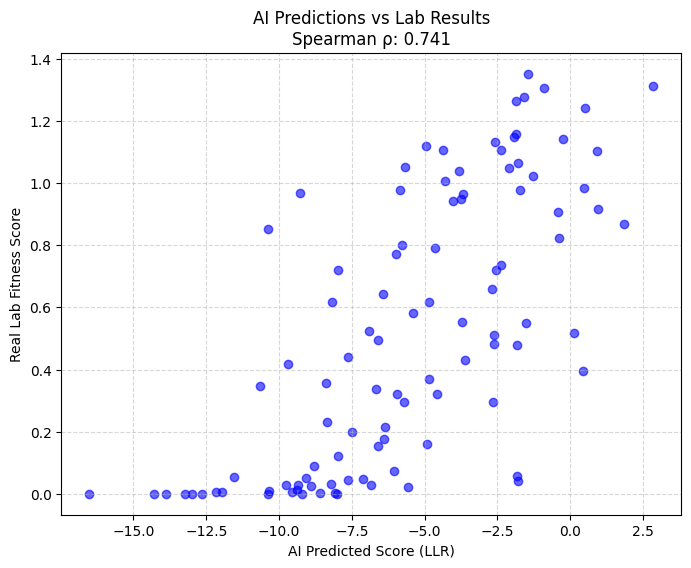

In [20]:
from scipy.stats import spearmanr
import matplotlib.pyplot as plt

# 1. Sample 100 random mutations from the lab dataset so it runs quickly
sample_data = lab_data.dropna(subset=["DMS_score"]).sample(100, random_state=42)

print(f"Scoring {len(sample_data)} mutations... (this will take ~10 seconds)")

# 2. Score them all using our AI engine
predicted_scores = []
for mutant in sample_data["mutant"]:
    position = int(mutant[1:-1])
    new_aa = mutant[-1]

    score = score_mutation(wild_type_sequence, position, new_aa)
    predicted_scores.append(score)

sample_data["AI_Score"] = predicted_scores

# 3. Calculate the Spearman Rank Correlation
rho, p_value = spearmanr(sample_data["AI_Score"], sample_data["DMS_score"])
print(f"\nSpearman Rank Correlation (ρ): {rho:.3f}")
print(f"Statistical Significance (p-value): {p_value:.4e}")

# 4. Plot the results to visually see the AI vs Lab relationship
plt.figure(figsize=(8, 6))
plt.scatter(sample_data["AI_Score"], sample_data["DMS_score"], alpha=0.6, c="blue")
plt.title(f"AI Predictions vs Lab Results\nSpearman ρ: {rho:.3f}")
plt.xlabel("AI Predicted Score (LLR)")
plt.ylabel("Real Lab Fitness Score")
plt.grid(True, linestyle="--", alpha=0.5)
plt.show()

Scaling up... Preparing to score all 4783 mutations.


AI Scoring Progress:   0%|          | 0/4783 [00:00<?, ?it/s]


Final Full-Dataset Spearman Correlation (ρ): 0.738


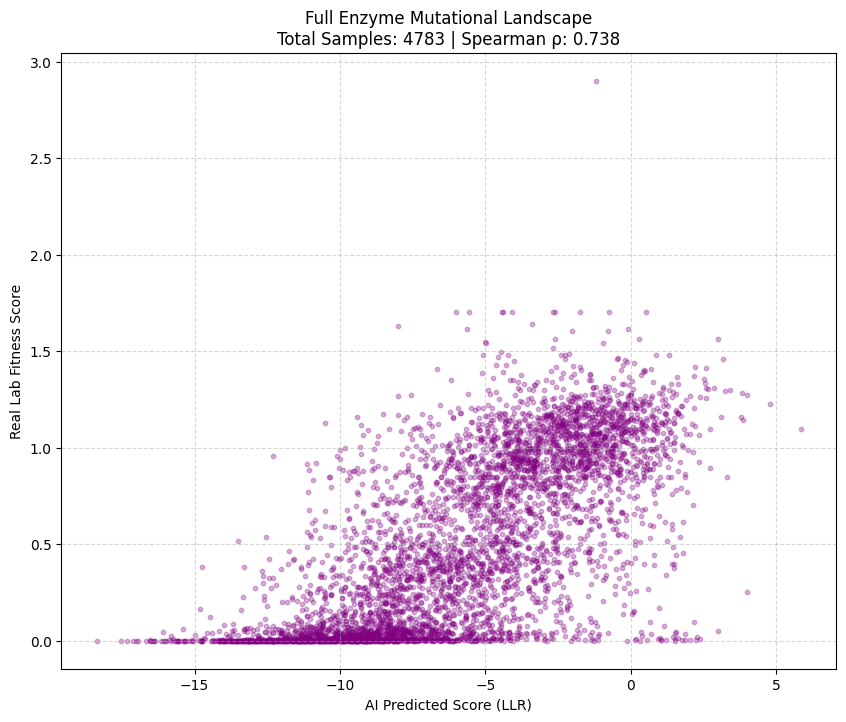

In [21]:
import pandas as pd
from scipy.stats import spearmanr
import matplotlib.pyplot as plt
from tqdm.notebook import tqdm

# 1. Grab every single valid mutation from the lab data
full_data = lab_data.dropna(subset=["DMS_score"]).copy()
total_mutations = len(full_data)
print(f"Scaling up... Preparing to score all {total_mutations} mutations.")

# 2. Score them all (using tqdm to show a progress bar)
predicted_scores = []
for mutant in tqdm(full_data["mutant"], desc="AI Scoring Progress"):
    position = int(mutant[1:-1])
    new_aa = mutant[-1]

    score = score_mutation(wild_type_sequence, position, new_aa)
    predicted_scores.append(score)

full_data["AI_Score"] = predicted_scores

# 3. Calculate the true Spearman correlation across the massive dataset
rho_full, p_value_full = spearmanr(full_data["AI_Score"], full_data["DMS_score"])
print(f"\nFinal Full-Dataset Spearman Correlation (ρ): {rho_full:.3f}")

# 4. Plot the massive scatter graph
plt.figure(figsize=(10, 8))
# We make the dots smaller (s=10) and more transparent (alpha=0.3) so we can see density
plt.scatter(full_data["AI_Score"], full_data["DMS_score"], alpha=0.3, c="purple", s=10)
plt.title(f"Full Enzyme Mutational Landscape\nTotal Samples: {total_mutations} | Spearman ρ: {rho_full:.3f}")
plt.xlabel("AI Predicted Score (LLR)")
plt.ylabel("Real Lab Fitness Score")
plt.grid(True, linestyle="--", alpha=0.5)
plt.show()